In [1]:
import os

os.environ["CUDA_VISIBLE_DEVICES"] = "0,1,2,3"  
# os.environ["CUDA_VISIBLE_DEVICES"] = "2,3"  
from torch import nn


import numpy as np                                                                  
import torch                                          

                              
from transformers import AutoModelForCausalLM, AutoTokenizer  
from tqdm import tqdm
import matplotlib.pyplot as plt  
import torch.nn.functional as F
import gc
import re
import copy

import sys
sys.path.append('..')
import JCBScope_utils

# Move to GPU with optimal dtype
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
device = "cpu"


/home/jl3499/conda/LLM1/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/home/jl3499/conda/LLM1/lib/python3.12/site-packages/transformers/utils/hub.py:110: FutureWarning: Using `TRANSFORMERS_CACHE` is deprecated and will be removed in v5 of Transformers. Use `HF_HOME` instead.
  warnings.warn(


In [2]:
# mode = 'Temperature'
mode = 'Semantic'

if mode not in ["Temperature", "Semantic"]:
    raise ValueError(f"Invalid mode '{mode}'. Mode must be either 'Temperature' or 'Semantic'.")

In [3]:
# Load the tokenizer and model

# model_name = "meta-llama/Llama-3.2-1B"
# model_name = "meta-llama/Llama-3.2-3B"
model_name = "meta-llama/Llama-3.1-8B"
model_name_short = model_name.split("/")[-1]
if device == "cpu":
    tokenizer = AutoTokenizer.from_pretrained(model_name)
    model = AutoModelForCausalLM.from_pretrained(model_name)
    model = model.to(device)
else:
    tokenizer = AutoTokenizer.from_pretrained(model_name, device_map="auto")
    model = AutoModelForCausalLM.from_pretrained(model_name, device_map="auto")

Loading checkpoint shards: 100%|██████████| 4/4 [00:02<00:00,  1.82it/s]


In [27]:
front_pad = 0
back_pad = 0
top_k_fraction = 0.3
# top_k_fraction = 0.1
# top_k_fraction = 0.2

front_strip = 26
back_strip = 16
# random_ablation = True
random_ablation = False
# num_prompts = 20
num_prompts = 200


# Get special tokens if available
bos_token_id = tokenizer.bos_token_id if tokenizer.bos_token_id is not None else tokenizer.cls_token_id
eos_token_id = tokenizer.eos_token_id if tokenizer.eos_token_id is not None else tokenizer.sep_token_id


In [28]:
def change_in_max_log_p_with_ablation(string, top_k_fraction=0.1, verbose=True, random_ablation = False):
    """Optimized: single model load, retain_graph=False, free logits before ablation."""
    input_ids_list = tokenizer(string, add_special_tokens=False)["input_ids"]
    if eos_token_id is not None:
        input_ids_list += [eos_token_id] * back_pad

    embedding_layer = model.get_input_embeddings()
    embed_device = embedding_layer.weight.device

    input_ids = torch.tensor([input_ids_list], dtype=torch.long).to(embed_device)
    attention_mask = torch.ones_like(input_ids, device=embed_device)
    assert input_ids.max() < model.config.vocab_size
    seq_len = input_ids.size(1)

    decoded_tokens = [tokenizer.decode(tok.item(), skip_special_tokens=True) for tok in input_ids[0]]

    def get_token_indices_for_substring(tokens, substring):
        full = "".join(tokens)
        exclude_indices = set()
        start = 0
        while True:
            pos = full.find(substring, start)
            if pos == -1:
                break
            end = pos + len(substring)
            cumlen = 0
            for i, t in enumerate(tokens):
                tok_end = cumlen + len(t)
                if tok_end > pos and cumlen < end:
                    exclude_indices.add(i)
                cumlen = tok_end
            start = pos + 1
        return exclude_indices

    base_indices = [idx for idx in range(front_pad, len(decoded_tokens), 1)][front_strip:-back_strip]
    exclude_words = ("Premise:", ". Hypothesis:")
    exclude_indices = set().union(*(get_token_indices_for_substring(decoded_tokens, w) for w in exclude_words))
    grad_idx = [idx for idx in base_indices if idx not in exclude_indices]
    tick_label_text = [decoded_tokens[idx] for idx in grad_idx]

    d_model = embedding_layer.embedding_dim
    residual = nn.Parameter(torch.zeros(len(grad_idx), d_model, device=embed_device))
    presence = torch.ones(len(decoded_tokens), 1, device=embed_device)

    forward_pass = JCBScope_utils.customize_forward_pass(
        model, residual, presence, input_ids, grad_idx, attention_mask
    )
    hidden_norm_as_loss = (mode == 'Temperature')
    loss_position = seq_len - 2

    if verbose:
        print(f"Computing {mode} Scope...")
    n_tokens = len(grad_idx)
    n_top = max(1, int(n_tokens * top_k_fraction))
    if random_ablation:
        with torch.no_grad():
            _, logits_orig = forward_pass(
                loss_position=loss_position,
                hidden_norm_as_loss=hidden_norm_as_loss,
                unnormalized_logits=True,
                tie_input_output_embed=False,
            )
        grad_vals = None
        ablated_indices = np.random.choice(n_tokens, size=min(n_top, n_tokens), replace=False)
    else:
        loss, logits_orig = forward_pass(
            loss_position=loss_position,
            hidden_norm_as_loss=hidden_norm_as_loss,
            unnormalized_logits=True,
            tie_input_output_embed=False,
        )
        grads = torch.autograd.grad(loss, residual, retain_graph=False)[0]
        grad_vals = grads.norm(dim=-1).squeeze().cpu().numpy()
        if grad_vals.ndim > 1:
            grad_vals = grad_vals.squeeze()
        ablated_indices = grad_vals.argsort()[::-1][:n_top]
        del loss

    max_idx_orig = logits_orig[loss_position].argmax().item()
    max_log_prob_orig = torch.log_softmax(logits_orig[loss_position], dim=-1)[max_idx_orig].item()
    gc.collect()
    torch.cuda.empty_cache()

    presence_ablated = presence.clone()
    for i in ablated_indices:
        presence_ablated[grad_idx[int(i)], 0] = 0.0

    forward_pass_ablated = JCBScope_utils.customize_forward_pass(
        model, residual, presence_ablated, input_ids, grad_idx, attention_mask
    )
    with torch.no_grad():
        _, logits_ablated = forward_pass_ablated(
            loss_position=loss_position,
            hidden_norm_as_loss=hidden_norm_as_loss,
            unnormalized_logits=True,
            tie_input_output_embed=False,
        )

    max_log_prob_ablated = torch.log_softmax(logits_ablated[loss_position], dim=-1)[max_idx_orig].item()
    delta_log_prob = max_log_prob_ablated - max_log_prob_orig

    true_token_id = input_ids[0, loss_position + 1].item()
    predicted_token_id = max_idx_orig
    true_token_str = tokenizer.decode([true_token_id])
    predicted_token_str = tokenizer.decode([predicted_token_id])
    match = (true_token_id == predicted_token_id)

    if verbose:
        print(string)
        dropped_words = []
        for i in ablated_indices:
            tok = input_ids[0, grad_idx[int(i)]].item()
            word = tokenizer.decode([tok]).strip()
            dropped_words.append(word)
        print(f"Words dropped: {dropped_words}")
        # print(f"True token: {true_token_str!r}")
        # print(f"Predicted token: {predicted_token_str!r}")
        # print(f"Match: {match}")

    return delta_log_prob, grad_vals, ablated_indices, tick_label_text, logits_orig, true_token_str, predicted_token_str

In [29]:
import json
from pathlib import Path

# Load prompts from JSON
prompts_path = Path("../data/esnli_prompts.json")
with open(prompts_path, "r", encoding="utf-8") as f:
    all_prompts_data = json.load(f)

# Handle both list-of-dicts and {prompts: [...]} formats
if isinstance(all_prompts_data, dict) and "prompts" in all_prompts_data:
    prompts_list = all_prompts_data["prompts"]
else:
    prompts_list = all_prompts_data


prompts_to_process = prompts_list[:num_prompts]

# Label: model name + scope type
label = f"{model_name_short}__{mode}_top{top_k_fraction}"
if random_ablation:
    label += "_random_drop"
results = []
for i, item in enumerate(tqdm(prompts_to_process, desc="Processing prompts")):
    print (f"processing {i+1} of {num_prompts} prompts")
    prompt = item["prompt"] if isinstance(item, dict) else item
    try:
        delta_log_prob, grad_vals, ablated_indices, tick_label_text, logits_orig, true_token, predicted_token = change_in_max_log_p_with_ablation(string=prompt, top_k_fraction=top_k_fraction, verbose=True, random_ablation=random_ablation)
        # Keep last successful result for visualization cells
        _last_grad_vals, _last_ablated, _last_tick = grad_vals, ablated_indices, tick_label_text
        _last_logits = logits_orig.detach().cpu() if hasattr(logits_orig, "cpu") else logits_orig
        del logits_orig
        entry = {
            "delta_log_prob": delta_log_prob,
            "prompt": prompt,
            "true_token": true_token,
            "predicted_token": predicted_token,
            "index": i,
        }
        if isinstance(item, dict):
            entry.update({k: v for k, v in item.items() if k != "prompt"})
        results.append(entry)
    except Exception as e:
        results.append({
            "delta_log_prob": None,
            "prompt": prompt,
            "error": str(e),
            "index": i,
        })



Processing prompts:   0%|          | 0/200 [00:00<?, ?it/s]

processing 1 of 200 prompts
Computing Semantic Scope...


Processing prompts:   0%|          | 1/200 [00:10<34:27, 10.39s/it]

Task: Determine the relationship between the premise and hypothesis. Answer with exactly one word: entailment, neutral, or contradiction.

Premise: Some people in blue shirts are standing up at an even with big letters spelling out the word "KRUNCH". Hypothesis: The people are wearing blue. Options:
- entailment
- neutral
- contradiction

Answer: entail
Words dropped: ['The', '"', 'with', 'RUN', 'are', 'even', 'spelling', 'the']
processing 2 of 200 prompts
Computing Semantic Scope...


Processing prompts:   1%|          | 2/200 [00:20<34:01, 10.31s/it]

...

Task: Determine the relationship between the premise and hypothesis. Answer with exactly one word: entailment, neutral, or contradiction.

Premise: Three women smiling and sitting down. Hypothesis: 3 people smile and sit down Options:
- entailment
- neutral
- contradiction

Answer: entail
Words dropped: ['and', 'and', 'women']
processing 199 of 200 prompts
Computing Semantic Scope...


Processing prompts: 100%|█████████▉| 199/200 [31:24<00:08,  8.73s/it]

Task: Determine the relationship between the premise and hypothesis. Answer with exactly one word: entailment, neutral, or contradiction.

Premise: Two men and a young lady with red hair play Wii together in the living room on a black leather sofa. Hypothesis: No one is playing video games. Options:
- entailment
- neutral
- contradiction

Answer: contradiction
Words dropped: ['and', 'men', 'is', 'Wii', 'with', 'on', 'young', 'games']
processing 200 of 200 prompts
Computing Semantic Scope...


Processing prompts: 100%|██████████| 200/200 [31:33<00:00,  9.47s/it]

Task: Determine the relationship between the premise and hypothesis. Answer with exactly one word: entailment, neutral, or contradiction.

Premise: People standing outside of an Irish Pub. Hypothesis: People are standing outside a pub. Options:
- entailment
- neutral
- contradiction

Answer: entail
Words dropped: ['are', 'of', 'a']


In [30]:
label

'Llama-3.1-8B__Semantic_top0.3'

In [31]:
# Save results
result_path = Path(f"../results/{label}_results.json")
result_path.parent.mkdir(parents=True, exist_ok=True)
with open(result_path, "w", encoding="utf-8") as f:
    json.dump({"label": label, "results": results}, f, indent=2, ensure_ascii=False)

print(f"Saved {len(results)} results to {result_path}")

# Restore last successful result for visualization cells
if "_last_grad_vals" in dir():
    grad_vals, ablated_indices, tick_label_text = _last_grad_vals, _last_ablated, _last_tick
    logits_orig = _last_logits

Saved 200 results to ../results/Llama-3.1-8B__Semantic_top0.3_results.json


In [32]:
## Summary of delta_log_prob for each prompt
for r in results:
    d = r.get("delta_log_prob")
    d_str = f"{d:.4f}" if d is not None else "ERROR"
    true_token = r.get('true_token', '')
    pred_token = r.get('predicted_token', '')
    is_correct = (true_token == pred_token)
    correctness = "✔" if is_correct else "✘"
    print(f"[{r['index']}] delta_log_prob={d_str}  true={true_token!r} pred={pred_token!r}  -> {correctness}")
    

[0] delta_log_prob=0.1737  true=' entail' pred=' entail'  -> ✔
[1] delta_log_prob=0.0723  true=' neutral' pred=' entail'  -> ✘
[2] delta_log_prob=-0.3944  true=' neutral' pred=' neutral'  -> ✔
[3] delta_log_prob=-0.1231  true=' contradiction' pred=' entail'  -> ✘
[4] delta_log_prob=-0.2344  true=' entail' pred=' entail'  -> ✔
[5] delta_log_prob=-0.8289  true=' contradiction' pred=' neutral'  -> ✘
[6] delta_log_prob=0.2188  true=' contradiction' pred=' entail'  -> ✘
[7] delta_log_prob=0.4217  true=' entail' pred=' entail'  -> ✔
[8] delta_log_prob=0.2297  true=' entail' pred=' entail'  -> ✔
[9] delta_log_prob=-0.8346  true=' contradiction' pred=' contradiction'  -> ✔
[10] delta_log_prob=0.6422  true=' contradiction' pred=' entail'  -> ✘
[11] delta_log_prob=-1.3011  true=' contradiction' pred=' contradiction'  -> ✔
[12] delta_log_prob=0.4521  true=' neutral' pred=' entail'  -> ✘
[13] delta_log_prob=0.2718  true=' neutral' pred=' entail'  -> ✘
[14] delta_log_prob=-0.4576  true=' neutral' p

In [33]:
# Report correct prediction rate
num_correct = sum(1 for r in results if r.get('true_token', '') == r.get('predicted_token', ''))
total = len(results)
accuracy = num_correct / total if total > 0 else 0.0
print(f"\nCorrect prediction rate: {num_correct}/{total} = {accuracy:.2%}")

# Report average ablation impact (mean |delta_log_prob|) and its variance
abs_deltas = [abs(r["delta_log_prob"]) for r in results if r.get("delta_log_prob") is not None]
avg_abs_delta = sum(abs_deltas) / len(abs_deltas) if abs_deltas else float("nan")
variance_abs_delta = (
    sum((x - avg_abs_delta) ** 2 for x in abs_deltas) / len(abs_deltas) if abs_deltas else float("nan")
)
print(f"Average ablation impact (mean |delta_log_prob|): {avg_abs_delta:.4f}")
print(f"Variance of ablation impact (|delta_log_prob|): {variance_abs_delta:.6f}")

# Save variance and average to master_results.json (label as key)
master_path = Path("../results/master_results.json")
master_path.parent.mkdir(parents=True, exist_ok=True)
master = {}
if master_path.exists():
    with open(master_path, "r", encoding="utf-8") as f:
        master = json.load(f)
entry = {
    "avg_abs_delta": avg_abs_delta if abs_deltas and not np.isnan(avg_abs_delta) else None,
    "variance_abs_delta": variance_abs_delta if abs_deltas and not np.isnan(variance_abs_delta) else None,
}
master[label] = entry
with open(master_path, "w", encoding="utf-8") as f:
    json.dump(master, f, indent=2)
print(f"\nSaved to {master_path} (label={label})")






Correct prediction rate: 77/200 = 38.50%
Average ablation impact (mean |delta_log_prob|): 0.3497
Variance of ablation impact (|delta_log_prob|): 0.084199

Saved to ../results/master_results.json (label=Llama-3.1-8B__Semantic_top0.3)


### Visualize prediction

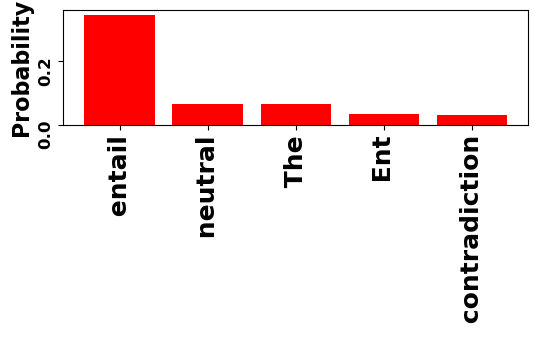

In [11]:
import torch
k = 5
logit_vector = logits_orig[-2].detach()             

# Compute softmax probabilities
probs = torch.softmax(logit_vector, dim=-1)

# Get top k probabilities and their indices
top_probs, top_indices = torch.topk(probs, k)
top_tokens = [tokenizer.decode([idx]) for idx in top_indices]

import matplotlib.pyplot as plt

plt.figure(figsize=(6,1.5), dpi=100)
bars = plt.bar(range(k), top_probs.cpu().numpy(), tick_label=top_tokens, color='red')
plt.xticks(rotation=90, fontweight='bold', fontsize=18)
# plt.xlabel('Token',rotation=180, fontweight='bold', fontsize=12)
plt.ylabel('Probability', fontweight='bold', fontsize=16,rotation=90)
plt.yticks(rotation=90, fontweight='bold', fontsize=12)
plt.gca().yaxis.set_major_locator(plt.MaxNLocator(nbins=2))  # increase number of ticks

# plt.title(f'Top {k} Tokens in Softmax of Logits')
plt.show()

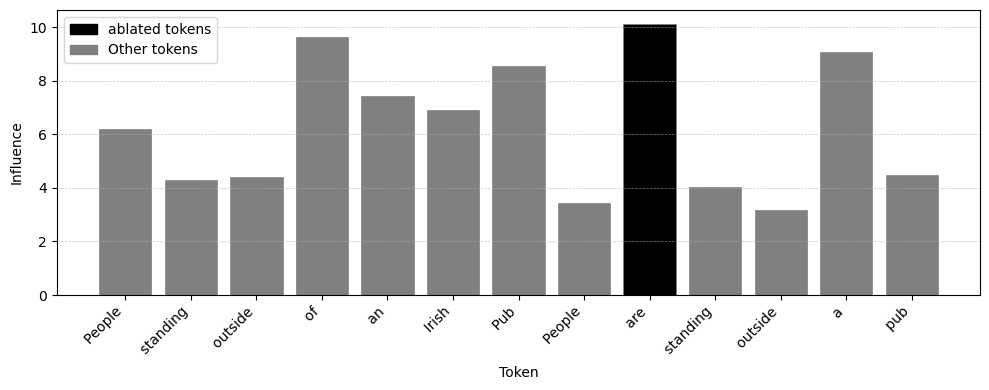

In [12]:


# Assign colors: gray for top tokens, blue otherwise
bar_colors = []
for i in range(len(grad_vals)):
    if i in ablated_indices:
        bar_colors.append('black')
    else:
        bar_colors.append('gray')

fig, ax = plt.subplots(figsize=(max(10, len(tick_label_text) * 0.5), 4))
ax.bar(range(len(tick_label_text)), grad_vals, color=bar_colors, edgecolor='gray', linewidth=0.5)
ax.set_xticks(range(len(tick_label_text)))
ax.set_xticklabels([t if t.strip() else '·' for t in tick_label_text], rotation=45, ha='right')
ax.set_xlabel('Token')
ax.set_ylabel('Influence')
ax.grid(True, which='both', axis='y', linestyle='--', linewidth=0.5, alpha=0.7)

legend_patches = [
    plt.matplotlib.patches.Patch(color='black', label=f'ablated tokens'),
    plt.matplotlib.patches.Patch(color='gray', label='Other tokens')
]
ax.legend(handles=legend_patches, loc='best')

plt.tight_layout()
plt.show()
